In [3]:
from __future__ import print_function

%matplotlib inline

import numpy
import matplotlib.pyplot as plt

# Boundary Value Problems:  Discretization (Masalah Nilai Batas: Diskretisasi)

Boundary Value Problems (BVP) discretization adalah proses mengubah persamaan diferensial kontinu (yang melibatkan turunan) menjadi sistem persamaan aljabar diskrit (angka-angka terbatas) agar bisa diselesaikan oleh komputer.


### Masalah Model
Masalah nilai batas (BVP) paling sederhana yang akan kita temui adalah versi satu dimensi dari persamaan Poisson:

$$u''(x) = f(x)$$

Biasanya, persamaan ini diselesaikan pada rentang jarak tertentu dengan kondisi batas tipe **Dirichlet** atau **Neumann**. Karena ada dua turunan dalam persamaan tersebut, maka hanya membutuhkan dua kondisi batas untuk mendapatkan solusi yang unik. Sebagai permulaannya, mari perhatikan masalah dasar dibawah berikut:

$$u''(x) = f(x) \quad \text{pada domain } \Omega = [a, b]$$ $$u(a) = \alpha, \quad u(b) = \beta$$

Jenis masalah nilai batas seperti ini sering kali muncul saat mencari kondisi keadaan tunak (steady-state) dari sebuah persamaan yang bergantung pada waktu. Contohnya, jika kita mencari solusi kondisi keadaan tunak untuk persamaan panas:

$$u_t(x, t) = \kappa u_{xx}(x, t) + \Psi(x, t) \quad \Omega = [0, T] \times [a, b]$$ $$u(x, 0) = u^0(x) \quad u(a, t) = \alpha(t) \quad u(b, t) = \beta(t)$$

Kita akan menyelesaikan persamaan tersebut dengan menganggap perubahan terhadap waktu adalah nol ($u_t = 0$)

$$
    u''(x) = - \frac{\Psi}{\kappa},
$$

sebuah versi persamaan Poisson di atas.

Pada dimensi spasial yang lebih tinggi, turunan kedua berubah menjadi Laplacian. Notasinya bervariasi, tetapi semua pernyataan ini setara:
$$\begin{aligned}
    \nabla^2 u(\vec{x~}) &= f(\vec{x~}) \\
    \Delta u(\vec{x~}) &= f(\vec{x~}) \\
    \sum^N_{i=1} u_{x_i x_i} &= f(\vec{x~}).
\end{aligned}$$

### Diskretisasi Satu Dimensi
Sebagai pendekatan pertama untuk menyelesaikan persamaan Poisson satu dimensi, mari kita bagi domain menjadi `m` titik, yang sering disebut *mesh* atau *grid*. Tujuan kita adalah untuk mendekati fungsi yang tidak diketahui $u(x)$ sebagai titik mesh $x_i$. Pertama, kita dapat menghubungkan jumlah titik mesh `m` dengan jarak antar titik mesh.

$$
    \Delta x = \frac{1}{m + 1}.
$$
Titik-titik grid $x_i$ dapat ditulis sebagai
$$
    x_i = a + i \Delta x.
$$

Kita dapat membiarkan $\Delta x$ bervariasi dan banyak rumus di atas hanya memiliki sedikit modifikasi, tetapi kita akan membahasnya di pekerjaan rumah. Secara notasi, kita juga akan mengadopsi notasi
$$
    U_i \approx u(x_i)
$$
sehingga $U_i$ adalah solusi perkiraan pada titik-titik grid dan mempertahankan huruf kecil $u$ untuk menunjukkan solusi sebenarnya.

Untuk menyederhanakan pembahasan kita, mari kita pertimbangkan ODE (Persamaan Diferensial Biasa).
$$
    u''(x) = f(x) \quad \Omega = [0, 1] \\
    u(0) = \alpha \quad u(1) = \beta.
$$

Dengan menerapkan aproksimasi selisih terpusat orde ke-2 untuk turunan ke-2, kita peroleh persamaan berikut:
$$
    D^2 U_i = \frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1})
$$
sehingga kita akhirnya mendapatkan ekspresi aljabar perkiraan di setiap titik grid dari
$$
    \frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i) \quad i = 1, 2, 3, \ldots, m.
$$

Perhatikan pada titik ini bahwa persamaan aljabar ini saling terkait karena setiap $U_i$ bergantung pada tetangganya. Ini berarti kita dapat menuliskannya sebagai sistem persamaan yang saling terkait.
$$
    A U = F.
$$

#### Tuliskan sistem persamaan tersebut.
$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i) \quad i = 1, 2, 3, \ldots, m.
$$
Perhatikan kondisi batasnya!

$$
    \frac{1}{\Delta x^2} \begin{bmatrix}
    -2 &  1 &    &    &    \\
     1 & -2 &  1 &    &    \\
       &  1 & -2 &  1 &    \\
       &    &  1 & -2 &  1 \\
       &    &    &  1 & -2 \\
    \end{bmatrix} \begin{bmatrix}
        U_1 \\ U_2 \\ U_3 \\ U_4 \\ U_5
    \end{bmatrix} = 
    \begin{bmatrix}
        f(x_1) - \frac{\alpha}{\Delta x^2} \\ f(x_2) \\ f(x_3) \\ f(x_4) \\ f(x_5) - \frac{\beta}{\Delta x^2} \\
    \end{bmatrix}.
$$

### Contoh
Ingin menyelesaikan BVP (Best Value Problem)
$$
    u_{xx} = e^x, \quad x \in [0, 1] \quad \text{with} \quad u(0) = 0, \text{ and } u(1) = 3
$$
melalui pembentukan sistem persamaan linear.

$$\begin{aligned}
    u_{xx} &= e^x \\
    u_x &= A + e^x \\
    u &= Ax + B + e^x\\
    u(0) &= B + 1 = 0 \Rightarrow B = -1 \\
    u(1) &= A - 1 + e^{1} = 3 \Rightarrow A = 4 - e\\ 
    ~\\
    u(x) &= (4 - e) x - 1 + e^x
\end{aligned}$$

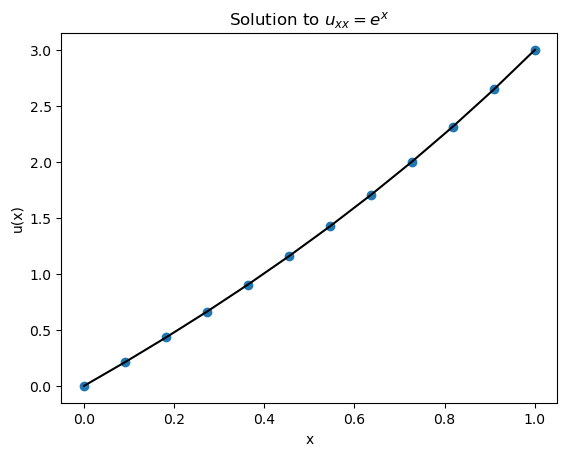

In [4]:
# Pengaturan masalah
a = 0.0 # Menentukan batas kiri domain x = 0
b = 1.0 # Menenntukan batas kanan domain x = 1
u_a = 0.0 # Nilai kondisi batas di kiri
u_b = 3.0 # Nilai kondisi batas di kanan
f = lambda x: numpy.exp(x) # Mendefinisikan fungsi ruas kanan persamaan diferensial, lambda digunakan untuk membuat fungsi singkat
u_true = lambda x: (4.0 - numpy.exp(1.0)) * x - 1.0 + numpy.exp(x) # Mendefinisikan solusi analitik sebenarnya dari persamaan diferensial tersebut.

# Diskritisasi
m = 10 # Jumlah yiyik interior (grid point)
x_bc = numpy.linspace(a, b, m + 2) # Membuat grid titik x dari 0 sampai 1 sebanyak m+2 titik. +2 karena termasuk dalam dua titik batas.
x = x_bc[1:-1] # Mengambil titik interior saja (tanpa titik batas).
delta_x = (b - a) / (m + 1) # Menghitung jarak antar grid (delta_x)

# Bangun matriks A
A = numpy.zeros((m, m)) # Membuat matriks nol ukuran m x m yang akan menjadi matriks sistem linear.
diagonal = numpy.ones(m) / delta_x**2 # Membuat nilai diagonal berdasarkan rumus beda hingga
A += numpy.diag(diagonal * -2.0, 0) # Mengisi diagonal utama matriks
A += numpy.diag(diagonal[:-1], 1) # Mengisi diagonal atas dengan nilai 1/delta_x^2
A += numpy.diag(diagonal[:-1], -1) # Mengisi diagonal bawah dengan nilai yang sama pada diagonal atas.

# Membangun RHS (Right Hand Side): Sisi kanan dalam referensi variabel.
b = f(x) # Menghitung nilai f(x) = e^x pada setiap titik interior
b[0] -= u_a / delta_x**2 # Menyesuaikan elemen pertama RHS karena kondisi batas kiri.
b[-1] -= u_b / delta_x**2 # Menyesuaikan elemen terakhir karena kondisi batas kanan.

# Menyelesaikan sistem
U = numpy.empty(m + 2) # Membuat array kosong untuk menyimpan solusi pada semua titik (termasuk batas).
U[0] = u_a # Mengisi solusi di batas kiri.
U[-1] = u_b # Mengisi solusi di batas kanan.
U[1:-1] = numpy.linalg.solve(A, b) # Menyelesaikan sistem linear

# Hasil Plot
fig = plt.figure() # Membuat objek figure untuk grafik.
axes = fig.add_subplot(1, 1, 1) # Membuat area plot.
axes.plot(x_bc, U, 'o', label="Computed") # Menampilkan solusi numerik sebagai titik
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # Menampilkan solusi analitik sebenarnya dengan garis hitam
axes.set_title("Solution to $u_{xx} = e^x$") # Memberi judul grafik.
axes.set_xlabel("x") # Label sumbu x.
axes.set_ylabel("u(x)") # Label sumbu y.
plt.show() # Menampilkan grafik.

### Analisis Kesalahan
Pertanyaan alami yang muncul mengingat aproksimasi $U_i$ kita adalah seberapa dekat aproksimasi ini dengan solusi sebenarnya $u(x)$ pada titik-titik grid $x_i$. Untuk menjawab pertanyaan ini, kita akan mendefinisikan kesalahan $E$ sebagai
$$
    E = U - \widehat{U}
$$
di mana $U$ adalah vektor solusi aproksimasi dan $\widehat{U}$ adalah vektor yang tersusun dari $u(x_i)$ sedemikian sehingga
$$
    \widehat{U_i} = u(x_i)
$$

Ini menyisakan $E$ sebagai vektor, sehingga kita sering bertanya bagaimana norma $E$ berperilaku jika diberikan $\Delta x$ tertentu. Untuk norma $\infty$, kita akan memiliki
$$
    ||E||_\infty = \max_{1 \leq i \leq m} |E_i| = \max_{1 \leq i \leq m} |U_i - u(x_i)|
$$

Jika kita dapat menunjukkan bahwa $||E||_\infty$ mendekati nol ketika $\Delta x \rightarrow 0$, maka kita dapat mengklaim bahwa solusi perkiraan $U_i$ pada titik grid mana pun $E_i \rightarrow 0$. Jika kita ingin menggunakan norma lain, kita sering mendefinisikan versi norma yang sedikit dimodifikasi yang juga mengandung lebar grid $\Delta x$ di mana
$\Delta x$ where
$$\begin{aligned}
    ||E||_1 &= \Delta x \sum^m_{i=1} |E_i| \\
    ||E||_2 &= \left( \Delta x \sum^m_{i=1} |E_i|^2 \right )^{1/2}
\end{aligned}$$
Ini disebut sebagai *norma fungsi grid*.


$E$ yang didefinisikan di atas dikenal sebagai *kesalahan global*. Salah satu tujuan utama kita sepanjang kursus ini adalah untuk memahami bagaimana $E$ berperilaku dengan mempertimbangkan faktor-faktor lain seperti yang akan kita definisikan nanti.

### Local Truncation Error
adalah kesalahan atau galat yang timbul pada satu langkah tunggal metode numerik (misalnya metode Euler atau Runge-Kutta) saat memecahkan persamaan diferensial. Ini terjadi karena pengabaian suku-suku berderajat tinggi dalam deret Taylor.

Kesalahan pemotongan lokal (Local Truncation Error/LTE) dapat didefinisikan dengan mengganti solusi perkiraan $U_i$ dengan solusi perkiraan $u(x_i)$. Karena persamaan aljabar merupakan perkiraan terhadap BVP asli, kita tidak mengharapkan bahwa solusi sebenarnya akan secara tepat memenuhi persamaan-persamaan ini, perbedaan yang dihasilkan inilah yang disebut LTE.

Untuk aproksimasi beda hingga satu dimensi kita dari atas, kita memiliki
$$
\frac{1}{\Delta x^2} (U_{i+1} - 2 U_i + U_{i-1}) = f(x_i).
$$

Mengganti $U_i$ dengan $u(x_i)$ dalam persamaan ini menghasilkan
$$
\tau_i = \frac{1}{\Delta x^2} (u(x_{i+1}) - 2 u(x_i) + u(x_{i-1})) - f(x_i).
$$


Dalam bentuk ini, LTE tidak begitu berguna, tetapi jika kita mengasumsikan $u(x)$ halus, kita dapat mengganti $u(x_i)$ dengan deret Taylor yang sesuai, mirip dengan apa yang kita lakukan untuk perbedaan hingga. Deret Taylor yang relevan adalah
$$
    u(x_{i \pm 1}) = u(x_i) \pm u'(x_i) \Delta x + \frac{1}{2} u''(x_i) \Delta x^2 \pm \frac{1}{6} u'''(x_i) \Delta x^3 + \frac{1}{24} u^{(4)}(x_i) \Delta x^4 + \mathcal{O}(\Delta x^5)
$$

Hal ini menghasilkan ekspresi untuk $\tau_i$ yaitu
$$\begin{aligned}
    \tau_i &= \frac{1}{\Delta x^2} \left [u''(x_i) \Delta x^2 + \frac{1}{12} u^{(4)}(x_i) \Delta x^4 + \mathcal{O}(\Delta x^5) \right ] - f(x_i) \\
    &= u''(x_i) + \frac{1}{12} u^{(4)}(x_i) \Delta x^2 + \mathcal{O}(\Delta x^4) - f(x_i) \\
    &= \frac{1}{12} u^{(4)}(x_i) \Delta x^2 + \mathcal{O}(\Delta x^4)
\end{aligned}$$
di mana kita perhatikan bahwa solusi sebenarnya akan memenuhi $u''(x) = f(x)$.

Selama $ u^{(4)}(x_i) $ tetap terbatas (halus), kita tahu bahwa $\tau_i \rightarrow 0$ ketika $\Delta x \rightarrow 0$

Kita juga dapat menulis vektor LTE sebagai
$$
    \tau = A \widehat{U} - F
$$
yang menyiratkan
$$
    A\widehat{U} = F + \tau.
$$
Perhatikan bahwa di sini yang dimaksud adalah stensil evaluasi solusi eksak, bukan fungsi yang diaproksimasi.


### Global Error
Yang sebenarnya ingin kita batasi adalah kesalahan global $E$. Untuk menghubungkan kesalahan global dan LTE, kita dapat mensubstitusikan $E = U - \widehat{U}$ ke dalam ekspresi kita untuk LTE untuk menemukan
$$
    A E = -\tau.
$$
Ini berarti bahwa kesalahan global adalah solusi dari sistem persamaan yang kita definisikan untuk aproksimasi, kecuali dengan $\tau$ sebagai fungsi pendorong, bukan $F$!

Hal ini juga menyiratkan bahwa kesalahan global $E$ dapat dianggap sebagai perkiraan untuk BVP serupa seperti yang kita mulai di mana
$$
    e''(x) = -\tau(x) \quad \Omega = [0, 1] \\
    e(0) = 0 \quad e(1) = 0.
$$
Kita dapat menyelesaikan ODE ini secara langsung dengan mengintegrasikan dua kali untuk menemukan orde utama.
$$\begin{aligned}
    e(x) &\approx -\frac{1}{12} \Delta x^2 u''(x) + \frac{1}{12} \Delta x^2 (u''(0) + x (u''(1) - u''(0))) \\
    &= \mathcal{O}(\Delta x^2) \rightarrow 0 \quad \text{as} \quad \Delta x \rightarrow 0.
\end{aligned}$$

### Stability
Kita telah menunjukkan bahwa analog kontinu dari $E$, $e(x)$, memang mendekati nol ketika $\Delta x \rightarrow 0$, tetapi bagaimana dengan $E$? Alih-alih menunjukkan sesuatu berdasarkan $e(x)$, mari kita lihat kembali sistem persamaan asli untuk kesalahan global.
$$
    A_{\Delta x} E_{\Delta x} = - \tau_{\Delta x}
$$
di mana kita sekarang menunjukkan realisasi khusus dari sistem tersebut dengan jarak grid yang sesuai, $\Delta x$.

Jika kita dapat membalikkan $A_{\Delta x}$, kita dapat menghitung $E_{\Delta x}$ secara langsung. Dengan asumsi bahwa kita dapat melakukannya dan mengambil norma yang sesuai, kita peroleh
$$\begin{aligned}
    E_{\Delta x} &= (A_{\Delta x})^{-1} \tau_{\Delta x} \\
    ||E_{\Delta x}|| &= ||(A_{\Delta x})^{-1} \tau_{\Delta x}|| \\
    & \leq ||(A_{\Delta x})^{-1} ||~|| \tau_{\Delta x}||
\end{aligned}$$

Kita sudah tahu bahwa $\tau_{\Delta x} \rightarrow 0$ ketika $\Delta x \rightarrow 0$ untuk contoh kita, jadi jika kita dapat membatasi norma matriks $(A_{\Delta x})^{-1}$ dengan konstanta $C$ untuk $\Delta x$ yang cukup kecil, maka kita dapat menuliskan batasan pada kesalahan global dari
$$
    ||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||
$$
menunjukkan bahwa $E_{\Delta x} \rightarrow 0 $ setidaknya secepat $\tau_{\Delta x} \rightarrow 0$.

Kita dapat menggeneralisasi pengamatan ini ke semua masalah BVP linier dengan menganggap bahwa kita memiliki aproksimasi beda hingga untuk BVP linier dalam bentuk
$$
    A_{\Delta x} U_{\Delta x} = F_{\Delta x},
$$
di mana $\Delta x$ adalah jarak antar grid.

Kita katakan aproksimasi tersebut *stabil* jika $(A_{\Delta x})^{-1}$ ada $\forall \Delta x < \Delta x_0$ dan terdapat konstanta $C$ sedemikian sehingga
$$
    ||(A_{\Delta x})^{-1}|| \leq C \quad \forall \Delta x < \Delta x_0.
$$

### Konsistensi
Ide terkait dan penting untuk diskretisasi persamaan diferensial parsial (PDE) adalah bahwa diskretisasi tersebut harus konsisten dengan persamaan yang kita aproksimasi. Jika
$$
    ||\tau_{\Delta x}|| \rightarrow 0 \quad \text{as}\quad  \Delta x \rightarrow 0
$$
maka kita katakan bahwa aproksimasi tersebut *konsisten* dengan persamaan diferensial.

### Konvergensi
Sekarang kita memiliki semua bagian untuk mengatakan sesuatu tentang kesalahan global $E$. Suatu metode dikatakan *konvergen* jika
$$
    ||E_{\Delta x}|| \rightarrow 0 \quad \text{as} \quad \Delta x \rightarrow 0.
$$

Jika suatu aproksimasi bersifat konsisten ($||\tau_{\Delta x}|| \rightarrow 0$ saat $\Delta x \rightarrow 0$) dan stabil ($||E_{\Delta x}|| \leq C ||\tau_{\Delta x}||$), maka aproksimasi tersebut konvergen.

Kita hanya menurunkan hal ini dalam kasus BVP linier, tetapi pada kenyataannya kriteria konvergensi ini seringkali terbukti benar untuk setiap aproksimasi beda hingga (dan bahkan lebih dari itu). Pernyataan konvergensi ini juga seringkali dapat diperkuat dengan mengatakan
$$
    \mathcal{O}(\Delta x^p) \text{ LTE } + \text{ stability } \Rightarrow \mathcal{O}(\Delta x^p) \text{ global error}.
$$

Ternyata bagian tersulit dari proses ini biasanya adalah pernyataan mengenai stabilitas. Pada bagian selanjutnya, kita akan melihat contoh sederhana kita tentang bagaimana kita dapat membuktikan stabilitas dalam norma-2.

### Stabilitas dalam Norma 2
Mengingat kembali definisi stabilitas kita, kita perlu menunjukkan bahwa untuk $A$ yang telah kita definisikan sebelumnya,
$$
    (A_{\Delta x})^{-1}
$$
ada dan
$$
    ||(A_{\Delta x})^{-1}|| \leq C \quad \forall \Delta x < \Delta x_0
$$
untuk sejumlah $C$.

Bagaimana kita tahu bahwa $(A_{\Delta x})^{-1}$ ada?

Sekarang kita dapat berasumsi bahwa $A$ memang dapat dibalik, tetapi dapatkah kita membatasi norma inversnya? Ingat bahwa norma-2 dari matriks simetris sama dengan jari-jari spektralnya,
$$
    ||A||_2 = \rho(A) = \max_{1\leq p \leq m} |\lambda_p|.
$$

Karena invers dari $A$ juga simetris, maka nilai eigen dari $A^{-1}$ adalah invers dari nilai eigen dari $A$, yang berarti bahwa
$$
    ||A^{-1}||_2 = \rho(A^{-1}) = \max_{1\leq p \leq m} \left| \frac{1}{\lambda_p} \right| = \frac{1}{\max_{1\leq p \leq m} \left| \lambda_p \right|}.
$$

Jika tidak ada satu pun dari $\lambda_p$ dari $A$ yang bernilai nol untuk $\Delta x$ yang cukup kecil dan sisanya bernilai hingga ketika $\Delta x \rightarrow 0$, maka kita telah menunjukkan stabilitas aproksimasi tersebut.

Nilai eigen dari matriks $A$ di atas dapat ditulis sebagai
$$
    \lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$
dengan vektor eigen yang bersesuaian $v^p$
$$
    v^p_j = \sin(p \pi j \Delta x)
$$
sebagai komponen ke-$j$ dengan $j = 1, \ldots, m$.

#### Periksa apakah ini memang pasangan nilai eigen dari matriks $A$.
$$
    \lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$

$$
    v^p_j = \sin(p \pi j \Delta x)
$$

$$\begin{aligned}
    (A v^p)_j &= \frac{1}{\Delta x^2} (v^p_{j-1} - 2 v^p_j + v^p_{j+1} ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi (j-1) \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi (j+1) \Delta x) ) \\
    &= \frac{1}{\Delta x^2} (\sin(p \pi j \Delta x) \cos(p \pi \Delta x) - 2 \sin(p \pi j \Delta x) + \sin(p \pi j \Delta x) \cos(p \pi \Delta x) \\
    &= \lambda_p v^p_j.
\end{aligned}$$

#### Hitung nilai eigen terkecil.
Jika kita dapat menunjukkan bahwa nilai eigen berada jauh dari titik asal, maka kita tahu bahwa $||A||_2$ akan terbatas. Dalam kasus ini, nilai eigennya negatif, jadi kita perlu menunjukkan bahwa nilai tersebut selalu kurang dari nol.
$$
    \lambda_p = \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1)
$$
Gunakan deret Taylor untuk mendapatkan gambaran tentang bagaimana perilaku ini terhadap $\Delta x$.

Dari ekspresi-ekspresi ini kita tahu bahwa nilai eigen terkecil adalah
$$\begin{aligned}
    \lambda_1 &= \frac{2}{\Delta x^2} (\cos(p \pi \Delta x) - 1) \\
    &= \frac{2}{\Delta x^2} \left (-\frac{1}{2} p^2 \pi^2 \Delta x^2 + \frac{1}{24} p^4 \pi^4 \Delta x^4 + \mathcal{O}(\Delta^6) \right ) \\
    &= -p^2 \pi^2 + \mathcal{O}(\Delta x^2).
\end{aligned}$$
Perhatikan bahwa ini juga memberi kita batas kesalahan karena nilai eigen ini juga akan mengarah ke nilai eigen terbesar dari matriks invers. Oleh karena itu, kita dapat mengatakan
$$
    ||E^{\Delta x}||_2 \leq ||(A^{\Delta x})^{-1}||_2 ||\tau^{\Delta x}||_2 \approx \frac{1}{\pi^2} ||\tau^{\Delta x}||_2.
$$

### Stabilitas dalam Norma $\infty$
Cara paling mudah untuk menunjukkan bahwa $||E||_\infty \rightarrow 0$ ketika $\Delta x \rightarrow 0$ adalah dengan menggunakan batas matriks.
$$
    ||E||_\infty \leq \frac{1}{\sqrt{\Delta x}} ||E||_2.
$$

Untuk contoh soal kita, kita menunjukkan bahwa $||E||_2 = \mathcal{O}(\Delta x^2)$, jadi ini menyiratkan bahwa setidaknya kita tahu bahwa $||E||_\infty = \mathcal{O}(\Delta x^{3/2})$. Ini disayangkan karena kita mengharapkan $||E||_\infty = \mathcal{O}(\Delta x^{2})$ karena diskretisasi. Untuk mengatasi masalah ini, mari kita kembali dan mempertimbangkan definisi stabilitas kita, tetapi kali ini mempertimbangkan norma $\infty$.

Matriks $A$ kita dapat dilihat sebagai sejumlah aproksimasi diskrit terhadap *fungsi Green* di setiap kolomnya. Hal ini lebih luas penerapannya nanti, jadi kita akan meluangkan waktu untuk meninjau teori fungsi Green dan menerapkannya pada contoh masalah sederhana kita.

### Fungsi Green
Pertimbangkan BVP dengan kondisi batas Dirichlet
$$
u''(x) = f(x) \quad \Omega = [0, 1] \\
u(0) = \alpha \quad u(1) = \beta.

$$
Pilih titik tetap $\bar{x} \in \Omega$, fungsi Green $G(x ; \bar{x})$ menyelesaikan BVP di atas dengan
$$
f(x) = \delta(x - \bar{x})
$$
dan $\alpha = \beta = 0$. Anda dapat menganggap ini sebagai hasil dari masalah keadaan tunak persamaan panas dengan kehilangan panas di suatu titik di dalam domain.

Untuk menemukan fungsi Green untuk masalah khusus kita, kita dapat mengintegrasikan tepat di sekitar titik $\bar{x}$ di dekat sumber fungsi $\delta$ untuk menemukan:

$$\begin{aligned}
\int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} u''(x) dx &= \int^{\bar{x} + \epsilon}_{\bar{x} - \epsilon} \delta(x - \bar{x}) dx \\
u'(\bar{x} + \epsilon) - u'(\bar{x} - \epsilon) &= 1
\end{aligned}$$

Mengingat bahwa menurut definisi integral dari fungsi $\delta$ harus bernilai 1 jika interval integrasi mencakup $\bar{x}$. Kita melihat bahwa lompatan turunan di $\bar{x}$ dari kiri dan kanan harus bernilai 1.

Setelah sedikit perhitungan aljabar, kita dapat menyelesaikan fungsi Green untuk model BVP kita sebagai berikut:
$$
    G(x; \bar{x}) = \left \{ \begin{aligned}
        (\bar{x} - 1) x & & 0 \leq x \leq \bar{x} \\
        \bar{x} (x - 1) & & \bar{x} \leq x \leq 1
    \end{aligned} \right . .
$$

Salah satu sifat penting dari persamaan diferensial parsial (atau persamaan diferensial biasa) linear secara umum adalah bahwa persamaan tersebut menunjukkan prinsip superposisi. Alasan kita memperhatikan hal ini pada fungsi Green adalah karena jika kita memiliki $f(x)$ yang terdiri dari dua fungsi $\delta$, maka solusinya adalah jumlah dari kedua fungsi Green yang bersesuaian. Misalnya, jika
$$
    f(x) = \delta(x - 0.25) + 2 \delta(x - 0.5)
$$
Maka,
$$
    u(x) = G(x ; 0.25) + 2 G(x ; 0.5).
$$

Tentu saja ini dapat diperluas ke sejumlah fungsi $\delta$ yang tak terbatas sehingga
$$
f(x) = \int^1_0 f(\bar{x}) \delta(x - \bar{x}) d\bar{x}
$$
dan oleh karena itu
$$
u(x) = \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Untuk memasukkan efek kondisi batas, kita dapat terus menambahkan fungsi Green ke solusi untuk menemukan solusi umum dari BVP asli kita sebagai berikut:
$$
u(x) = \alpha (1 - x) + \beta x + \int^1_0 f(\bar{x}) G(x ; \bar{x}) d\bar{x}.
$$

Jadi mengapa kita melakukan semua ini? Nah, representasi solusi fungsi Green di atas dapat dianggap sebagai operator linear pada fungsi $f(x)$. Ditulis dalam istilah yang mungkin lebih familiar, kita memiliki
$$
\mathcal{A} u = f \quad u = \mathcal{A}^{-1} f.

$$ Sekarang kita melihat bahwa operator linear kita $\mathcal{A}$ mungkin merupakan analog kontinu dari matriks diskrit kita $A$.

Untuk melanjutkan, kita akan memodifikasi matriks asli $A$ menjadi versi yang sedikit berbeda berdasarkan diskretisasi yang sama. Alih-alih memindahkan suku batas ke sisi kanan persamaan, kita akan memperkenalkan dua "variabel tak dikenal" baru, yang disebut *sel hantu*, yang akan ditempatkan di tepi grid. Kita akan memberi label $U_0$ dan $U_{m+1}$. Pada kenyataannya kita mengetahui nilai titik-titik ini, yaitu kondisi batas!

Sistem yang telah dimodifikasi kemudian terlihat seperti ini:
$$
    A = \frac{1}{\Delta x^2} \begin{bmatrix}
        \Delta x^2 & 0  \\
        1 & -2 & 1 \\
          &  1 & -2 & 1 \\
          &    & \ddots & \ddots & \ddots \\
          &    &        &      1 &     -2 & 1 \\
          &    &        &        &      1 & -2 & 1 \\
          &    &        &        &        &  0 & \Delta x^2
    \end{bmatrix} \quad \quad U = \begin{bmatrix}
        U_0 \\ U_1 \\ \vdots \\ U_m \\ U_{m+1}
    \end{bmatrix} \quad \quad F = \begin{bmatrix}
        \alpha \\ f(x_1) \\ \vdots \\ f(x_{m}) \\ \beta
    \end{bmatrix}  
$$
Hal ini memiliki keuntungan karena nantinya kita dapat menerapkan kondisi batas yang lebih umum dan mengisolasi ketergantungan aljabar pada kondisi batas. Kekurangannya adalah matriks tersebut tidak lagi memiliki bentuk sesederhana sebelumnya.

Mari kita akhirnya beralih ke bentuk matriks $A^{-1}$. Dengan memperkenalkan sedikit notasi tambahan, misalkan $A_{j}$ menyatakan kolom ke-j dan $A_{ij}$ menyatakan elemen ke-j dari matriks $A$.

Kita tahu bahwa
$$
    A A^{-1}_j = e_j
$$
di mana $e_j$ adalah vektor satuan dengan $1$ di baris ke-$j$ (kolom ke-$j$ dari matriks identitas).

Perhatikan bahwa sistem di atas memiliki beberapa kemiripan dengan versi diskrit dari masalah fungsi Green. Di sini $e_j$ mewakili fungsi $\delta$, $A$ adalah operator asli, dan $A^{-1}_j$ adalah efek yang diberikan oleh fungsi $\delta$ ke-$j$ (yang sesuai dengan $\bar{x}$) pada solusi lengkap.

Ternyata kita dapat menuliskan matriks invers secara langsung menggunakan fungsi Green (lihat LeVeque untuk detailnya) tetapi kita akhirnya mendapatkan
$$
    A^{-1}_{ij} = \Delta xG(x_i ; x_j) = \left \{ \begin{aligned}
        \Delta x (x_j - 1) x_i, & & i &= 1,2, \ldots j \\
        \Delta x (x_i - 1) x_j, & & i &= j, j+1, \ldots , m
    \end{aligned} \right . .
$$

Kita juga dapat menuliskan sisi kanan efektif dari sistem kita sebagai
$$
F = \alpha e_0 + \beta e_{m+1} + \sum^m_{j=1} f_j e_j
$$
dan akhirnya solusinya sebagai
$$
U = \alpha A^{-1}_{0} + \beta A^{-1}_{m+1} + \sum^m_{j=1} f_j A^{-1}_{j}
$$
yang elemen-elemennya adalah
$$
U_i = \alpha(1 - x_i) + \beta x_i + \Delta x \sum^m_{j=1} f_j G(x_i ; x_j).
$$

Baiklah, apa hasil dari semua ini? Nah, karena kita sekarang tahu bentuk dari $A^{-1}$, kita mungkin bisa mendapatkan norma $\infty$ dari matriks ini. Ingat bahwa norma $\infty$ dari sebuah matriks (yang diinduksi dari norma $\infty$) untuk sebuah vektor adalah
$$
|| C ||_\infty = \max_{0\leq i \leq m+1} \sum^{m+1}_{j=0} |C_{ij}|
$$

Perhatikan bahwa karena bentuk matriks $A^{-1}$, jumlah baris pertama adalah 

$$

\sum^{m+1}_{j=0} A_{0j}^{-1} = 1
$$

begitu pula baris terakhir $A^{-1}_{m+1}$. Kita juga tahu bahwa untuk baris lainnya $A^{-1}_{i,0} < 1$ dan $A^{-1}_{i,m+1} < 1$.

Baris-baris perantara juga semuanya dibatasi sebagai
$$
\sum^{m+1}_{j=0} |A^{-1}_{ij}| \leq 1 + 1 + m \Delta x < 3
$$
dengan menggunakan fakta yang kita ketahui bahwa
$$
\Delta x = \frac{1}{m+1}.
$$

Ini melengkapi penelusuran stabilitas kita karena sekarang kita dapat mengatakan secara pasti bahwa
$$
||A^{-1}||_\infty < 3 \quad \forall \Delta x.
$$

## Kondisi Batas Neumann

Seperti yang telah disebutkan sebelumnya, kita dapat menggabungkan jenis kondisi batas lainnya ke dalam diskretisasi kita menggunakan versi matriks yang telah dimodifikasi. Mari kita coba melakukan ini untuk masalah asli kita tetapi dengan satu sisi memiliki kondisi batas Neumann:
$$
u''(x) = f(x) \quad \Omega = [-1, 1] \\
u(-1) = \alpha \quad u'(1) = \sigma.
$$

**Latihan**

$$
u''(x) = f(x) \quad \Omega = [-1, 1] \\
u(-1) = \alpha \quad u'(1) = \sigma.

$$

$$
u(x) = -(5 + e) ​​x - (2 + e + e^{-1}) + e^x
$$

Jelajahi penerapan kondisi batas Neumann dengan:
1. menggunakan ekspresi orde 1 satu sisi,
1. menggunakan ekspresi orde 2 terpusat, dan
1. menggunakan ekspresi orde 2 satu sisi

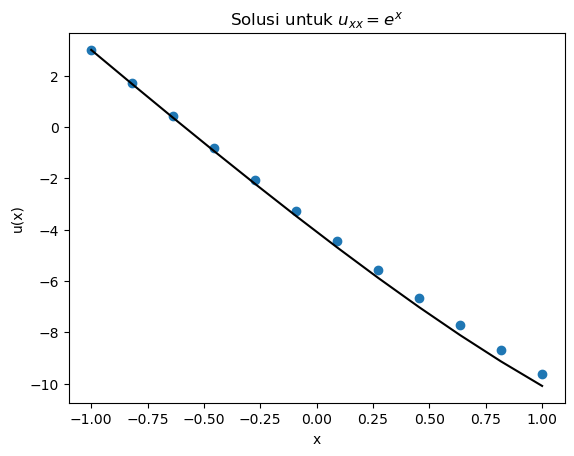

In [4]:
def solve_mixed_1st_order_one_sided(m): # Membuat fungsi untuk menyelesaikan persamaan diferensial dengan jumlah titik grid
    # Pengaturan Masalah 
    a = -1.0 # Menentukan domain masalah:
    b = 1.0 # Menentukan domain masalah:
    alpha = 3.0 # Nilai kondisi batas kiri
    sigma = -5.0 # Nilai turunan di batas kanan 
    f = lambda x: numpy.exp(x) # Mendefiniikan fungsi ruas kanan persamaan

    # Diskritisasi domain 
    x_bc = numpy.linspace(a, b, m + 2) # Membuat grid titik x dari -1 sampai 1 sebanyak m+2 titik (termasuk dua titik batas).
    x = x_bc[1:-1] # Mengambil titik interior (tanpa batas).
    delta_x = (b - a) / (m + 1) # Menghitung jarak antara grid.

    # Membuat matriks A
    A = numpy.zeros((m + 2, m + 2)) # Membuat matriks sistem berukuran (m+2) x (m+2).
    diagonal = numpy.ones(m + 2) / delta_x**2 # Membuat nilai dasar untuk operator turunan kedua.
    A += numpy.diag(diagonal * -2.0, 0) # Mengisi diagonal utama matriks.
    A += numpy.diag(diagonal[:-1], 1) # Mengisi diagonal atas.
    A += numpy.diag(diagonal[:-1], -1) # Mengisi diagonal bawah.

    # Membuat RHS (Right Hand Side)
    b = f(x_bc) # Menghitung nilai f(x) = e^x pada semua titik grid.

    # Menerapkan kondisi batas.
    # Kondisi Dirichlet di kiri
    A[0, 0] = 1.0 # Mengubah baris pertama matriks agar merepresentasikan: u(-1)=3.
    A[0, 1] = 0.0

    # Kondisi Neumann di kanan
    A[-1, -1] = 1.0 / (delta_x) # Menggunakan one-sided finite difference untuk turunan pertama.
    A[-1, -2] = -1.0 / (delta_x)

    b[0] = alpha # Memasukkan nilai batas kiri.
    b[-1] = sigma # Memasukkan kondisi turunan.

    # Menyelesaikan sistem persamaan
    U = numpy.linalg.solve(A, b) # Menyelesaikan sistem linear: AU = b, untuk mendapatkan nilai solusi di semua titik grid.

    return x_bc, U # Mengembalikan x_bc ke titik grid, u ke solusi numerik.


u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x) # Ini adalah solusi eksak dari persamaan diferensial dengan kondisi batas tersebut.
x_bc, U = solve_mixed_1st_order_one_sided(10) # Menjalankan solver dengan 10 titik interior.
    
# Hasil plot
fig = plt.figure() # Membuat figur grafik
axes = fig.add_subplot(1, 1, 1) # Membuat area plot
axes.plot(x_bc, U, 'o', label="Computed") # Membuat solusi numerik sebagai titik.
axes.plot(x_bc, u_true(x_bc), 'k', label="True") # Menampilkan solusi analitik sebagai garis hitam.
axes.set_title("Solusi untuk $u_{xx} = e^x$") # Judul grafik
axes.set_xlabel("x") # Label sumbu x
axes.set_ylabel("u(x)") # Label sumbu y
plt.show() # Menampilkan grafik

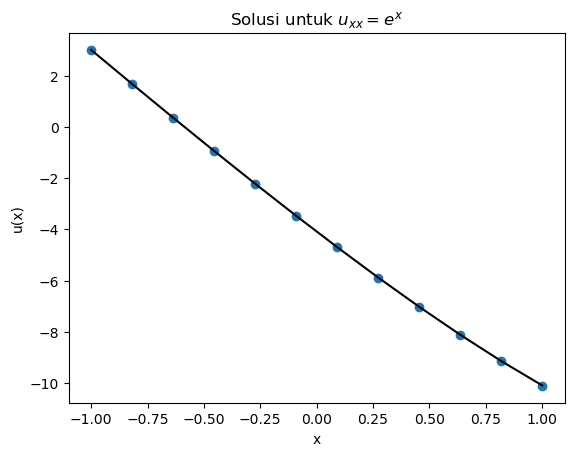

In [14]:
def solve_mixed_2nd_order_centered(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)

    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)

    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = -1.0 / (delta_x)
    A[-1, -2] =  1.0 / (delta_x)

    b[0] = alpha
    b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_centered(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solusi untuk $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

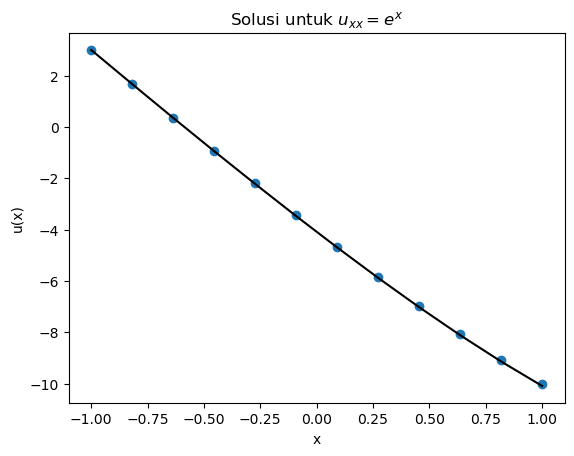

In [13]:
def solve_mixed_2nd_order_one_sided(m):
    # Problem setup
    a = -1.0
    b = 1.0
    alpha = 3.0
    sigma = -5.0
    f = lambda x: numpy.exp(x)
    
    # Descretization
    x_bc = numpy.linspace(a, b, m + 2)
    x = x_bc[1:-1]
    delta_x = (b - a) / (m + 1)
    
    # Construct matrix A
    A = numpy.zeros((m + 2, m + 2))
    diagonal = numpy.ones(m + 2) / delta_x**2
    A += numpy.diag(diagonal * -2.0, 0)
    A += numpy.diag(diagonal[:-1], 1)
    A += numpy.diag(diagonal[:-1], -1)

    # Construct RHS
    b = f(x_bc)

    # Boundary conditions
    A[0, 0] = 1.0
    A[0, 1] = 0.0
    A[-1, -1] = 3.0 / (2.0 * delta_x)
    A[-1, -2] = -4.0 / (2.0 * delta_x)
    A[-1, -3] = 1.0 / (2.0 * delta_x)

    b[0] = alpha
    b[-1] = sigma

    # Solve system
    U = numpy.linalg.solve(A, b)

    return x_bc, U

x_bc, U = solve_mixed_2nd_order_one_sided(10)
    
# Plot result
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x_bc, U, 'o', label="Computed")
axes.plot(x_bc, u_true(x_bc), 'k', label="True")
axes.set_title("Solusi untuk $u_{xx} = e^x$")
axes.set_xlabel("x")
axes.set_ylabel("u(x)")
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\USER\AppData\Local\Temp\ipykernel_23288\1737631319.py:38: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta x$")


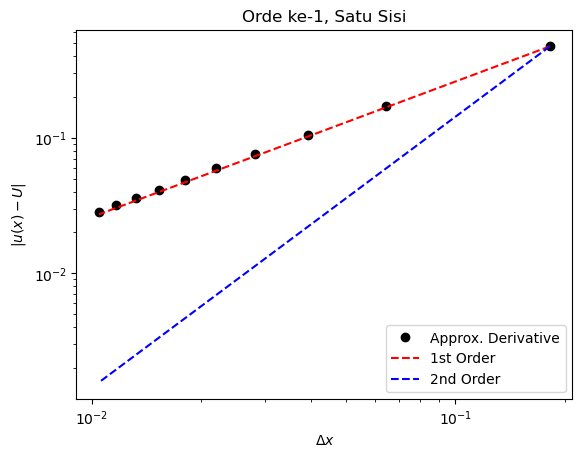

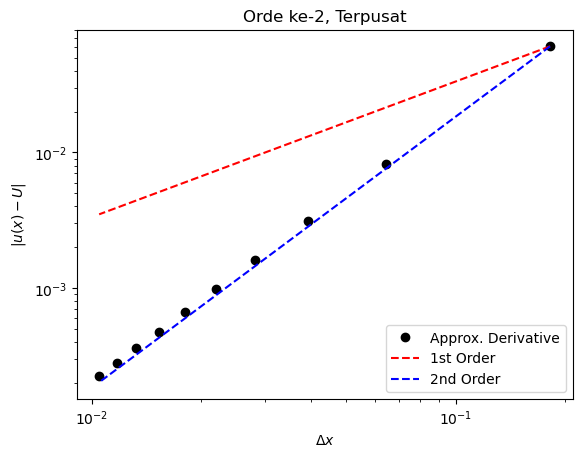

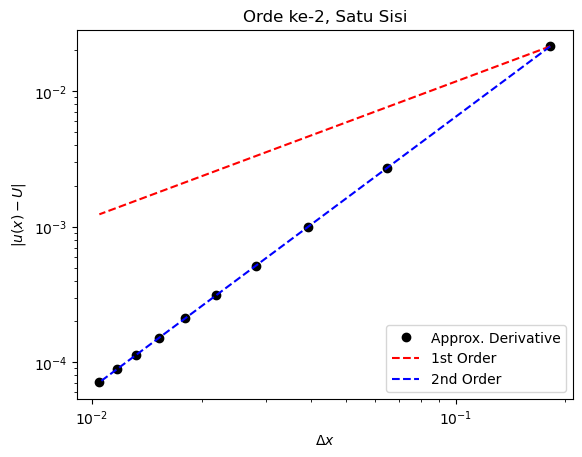

In [12]:
# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)
u_true = lambda x: -(5.0 + numpy.exp(1.0)) * x - (2.0 + numpy.exp(1.0) + numpy.exp(-1.0)) + numpy.exp(x)

# Compute the error as a function of delta_x
m_range = numpy.arange(10, 200, 20)
delta_x = numpy.empty(m_range.shape)
error = numpy.empty((m_range.shape[0], 3))
for (i, m) in enumerate(m_range):
    
    x = numpy.linspace(a, b, m + 2)
    delta_x[i] = (b - a) / (m + 1)

    # Compute solution
    _, U = solve_mixed_1st_order_one_sided(m)
    error[i, 0] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    _, U = solve_mixed_2nd_order_one_sided(m)
    error[i, 1] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    _, U = solve_mixed_2nd_order_centered(m)
    error[i, 2] = numpy.linalg.norm(U - u_true(x), ord=numpy.inf)
    
titles = ["Orde ke-1, Satu Sisi", "Orde ke-2, Terpusat", "Orde ke-2, Satu Sisi"]
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
for i in range(3):
    fig = plt.figure()
    axes = fig.add_subplot(1, 1, 1)

    axes.loglog(delta_x, error[:, i], 'ko', label="Approx. Derivative")

    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 1.0) * delta_x**1.0, 'r--', label="1st Order")
    axes.loglog(delta_x, order_C(delta_x[0], error[0,i], 2.0) * delta_x**2.0, 'b--', label="2nd Order")
    axes.legend(loc=4)
    axes.set_title(titles[i])
    axes.set_xlabel("$\Delta x$")
    axes.set_ylabel("$|u(x) - U|$")


plt.show()

U = solve_mixed_1st_order_one_sided(10)
U = solve_mixed_2nd_order_one_sided(10)
U = solve_mixed_2nd_order_centered(10)

## Eksistensi dan Keunikan

Salah satu pertanyaan yang harus diajukan sebelum memulai solusi numerik untuk persamaan apa pun adalah apakah persamaan aslinya *terdefinisi dengan baik*. Terdefinisi dengan baik didefinisikan sebagai masalah yang memiliki solusi unik dan bergantung secara kontinu pada data masukan (kondisi awal dan kondisi batas adalah contohnya).

Pertimbangkan BVP yang telah kita eksplorasi, tetapi sekarang tambahkan kondisi batas Neumann yang ketat
$$
u''(x) = f(x) \quad \Omega = [0, 1] \\
u'(0) = \sigma_0 \quad u'(1) = \sigma_1.

$$
Kita dapat dengan mudah mendiskretisasi ini menggunakan salah satu metode yang telah kita kembangkan di atas, tetapi kita menemui masalah.

In [9]:
# Problem setup
a = -1.0
b = 1.0
alpha = 3.0
sigma = -5.0
f = lambda x: numpy.exp(x)

# Descretization
m = 50
x_bc = numpy.linspace(a, b, m + 2)
x = x_bc[1:-1]
delta_x = (b - a) / (m + 1)

# Construct matrix A
A = numpy.zeros((m + 2, m + 2))
diagonal = numpy.ones(m + 2) / delta_x**2
A += numpy.diag(diagonal * -2.0, 0)
A += numpy.diag(diagonal[:-1], 1)
A += numpy.diag(diagonal[:-1], -1)

# Construct RHS
b = f(x_bc)

# Boundary conditions
A[0, 0] = -1.0 / delta_x
A[0, 1] = 1.0 / delta_x
A[-1, -1] = -1.0 / (delta_x)
A[-1, -2] =  1.0 / (delta_x)

b[0] = delta_x / 2.0 * f(x_bc[0]) - alpha
b[-1] = delta_x / 2.0 * f(x_bc[-1]) - sigma

# Solve system
try:
    U = numpy.linalg.solve(A, b)
except numpy.linalg.LinAlgError as e:
    print(e)
    import traceback
    traceback.print_exc()

Singular matrix


Traceback (most recent call last):
  File "C:\Users\USER\AppData\Local\Temp\ipykernel_23288\3331781132.py", line 35, in <module>
    U = numpy.linalg.solve(A, b)
  File "c:\Users\USER\miniconda3\envs\Metkom1\Lib\site-packages\numpy\linalg\_linalg.py", line 471, in solve
    r = gufunc(a, b, signature=signature)
  File "c:\Users\USER\miniconda3\envs\Metkom1\Lib\site-packages\numpy\linalg\_linalg.py", line 163, in _raise_linalgerror_singular
    raise LinAlgError("Singular matrix")
numpy.linalg.LinAlgError: Singular matrix


Kita dapat melihat mengapa $A$ bersifat singular, vektor konstan $e = [1, 1, 1, 1, 1,\ldots, 1]^T$ sebenarnya berada di ruang nol dari $A$. Metode numerik kita sebenarnya telah menunjukkan bahwa masalah ini *ill-posed*! Memang, karena kondisi batas hanya pada turunan, ada sejumlah solusi tak terbatas untuk BVP (ini juga dapat terjadi jika tidak ada solusi).

Cara lain untuk memahami mengapa demikian adalah dengan memeriksa kembali masalah ini sebagai masalah keadaan tunak yang berasal dari persamaan panas. Pertimbangkan persamaan panas dengan $\sigma_0 = \sigma_1 = 0$ dan $f(x) = 0$. Pengaturan ini akan mempertahankan panas apa pun di dalam batang karena tidak ada yang dapat keluar melalui ujung batang. Bahkan, solusi untuk masalah keadaan tunak hanyalah mendistribusikan kembali panas di dalam batang secara merata di seluruh batang berdasarkan kondisi awal. Kita kemudian akan memiliki solusi
$$
u(x) = \int^1_0 u^0(x) dx = C.
$$

Masalahnya terletak pada kenyataan bahwa masalah keadaan tunak (steady-state problem) tidak mengetahui informasi ini dengan sendirinya. Ini berarti bahwa BVP sebagaimana adanya dapat memilih $C$ mana pun dan itu akan menjadi solusi.

Solusinya serupa jika kita memiliki pengaturan yang sama kecuali $f(x) \neq 0$. Sekarang kita menambahkan atau mengurangi panas pada batang. Dalam kasus ini mungkin tidak ada keadaan tunak sama sekali! Anda sebenarnya dapat menunjukkan bahwa jika penambahan dan pengurangan panas saling meniadakan, kita mungkin benar-benar memiliki solusi jika
$$
\int^1_0 f(x) dx = 0
$$
yang mengarah lagi ke sejumlah solusi tak terbatas.

## Diskretisasi Linear Orde Kedua Umum

Sekarang mari kita jelaskan metode untuk menyelesaikan persamaan
$$
a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
u(a) = \alpha \quad u(b) = \beta.
$$

Cobalah diskretisasi ini menggunakan perbedaan hingga orde kedua dan tulis sistemnya untuk
$$
a(x) u''(x) + b(x) u'(x) + c(x) u(x) = f(x) \quad \Omega = [a, b] \\
u(a) = \alpha \quad u(b) = \beta.
$$

Aproksimasi beda hingga orde kedua umum untuk persamaan di atas dapat ditulis sebagai
$$
a_i \frac{U_{i+1} - 2 U_i + U_{i-1}}{\Delta x^2} + b_i \frac{U_{i+1} - U_{i-1}}{2 \Delta x} + c_i U_i = f_i
$$
yang menghasilkan entri matriks
$$
A_{i,i} = -\frac{2 a_i}{\Delta x^2} + c_i
$$
pada diagonal dan
$$
A_{i,i\pm1} = \frac{a_i}{\Delta x^2} \pm \frac{b_i}{2 \Delta x}
$$
pada sub-diagonal. Kita dapat menghilangkan kondisi batas dengan menggunakan pendekatan titik-titik hantu atau dengan memasukkannya ke dalam evaluasi sisi kanan.

### Contoh:

Pertimbangkan masalah konduksi panas keadaan tunak dengan variabel $\kappa(x)$ sehingga
$$
(\kappa(x) u'(x))' = f(x), \quad \Omega = [0, 1] \\
u(0) = \alpha \quad u(1) = \beta
$$

Berdasarkan aturan rantai, kita tahu:
$$
\kappa(x) u''(x) + \kappa'(x) u'(x) = f(x).

$$

Ternyata dalam kasus ini, pendekatan ini bukanlah pendekatan terbaik untuk menyelesaikan masalah. Dalam banyak kasus, lebih baik mendiskretisasi bentuk asli fisika daripada formulasi yang mungkin setara. Untuk mendemonstrasikan hal ini, mari kita coba membangun sistem untuk menyelesaikan persamaan asli
$$
(\kappa(x) u'(x))' = f(x).

$$

Pertama, kita akan mengaproksimasi ekspresi tersebut
$$
\kappa(x) u'(x)
$$
tetapi pada titik-titik yang berada di tengah antara titik $x_i$, yaitu $x_{i + 1/2}$.

Kita juga akan menganggap aproksimasi ini secara efektif sebagai $\Delta x / 2$ dan menemukan
$$
\kappa(x_{i+1/2}) u'(x_{i+1/2}) = \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x}.
$$

Sekarang, dengan mengambil aproksimasi ini dan membedakannya dengan selisih yang sama yang berpusat di $x_{i-1/2}$, diperoleh:
$$\begin{aligned}
    (\kappa(x_i) u'(x_i))' &= \frac{1}{\Delta x} \left [ \kappa_{i+1/2} \frac{U_{i+1} - U_i}{\Delta x} - \kappa_{i-1/2} \frac{U_{i} - U_{i-1}}{\Delta x} \right ] \\
    &= \frac{\kappa_{i+1/2}U_{i+1} - \kappa_{i+1/2} U_i -\kappa_{i-1/2} U_{i} + \kappa_{i-1/2} U_{i-1}}{\Delta x^2} \\ 
    &= \frac{\kappa_{i+1/2}U_{i+1} - (\kappa_{i+1/2} - \kappa_{i-1/2}) U_i + \kappa_{i-1/2} U_{i-1}}{\Delta x^2}
\end{aligned}$$

Perhatikan bahwa formulasi ini sebenarnya setara dengan $\mathcal{O}(\Delta x^2)$. Entri matriksnya adalah
$$\begin{aligned}
A_{i,i} = -\frac{\kappa_{i+1/2} - \kappa_{i-1/2}}{\Delta x^2} \\
A_{i,i \pm 1} = \frac{\kappa_{i\pm 1/2}}{\Delta x^2}.
\end{aligned}$$
Perhatikan bahwa diskretisasi yang terakhir ini simetris. Hal ini akan berdampak pada seberapa baik atau cepat kita dapat menyelesaikan sistem persamaan linear yang dihasilkan.

## Persamaan Non-Linear

Masalah model kita, persamaan Poisson, adalah BVP linear. Bagaimana kita mendekati masalah non-linear? Sebagai masalah model baru, mari kita pertimbangkan masalah pendulum non-linear. Sistem fisiknya adalah massa $m$ yang terhubung ke batang kaku tanpa massa dengan panjang $L$ yang dibiarkan berayun di sekitar suatu titik. Sudut $\theta(t)$ diambil dengan mengacu pada titik diam yang stabil dengan massa menggantung ke bawah.

Sistem ini dapat dijelaskan oleh:
$$
\theta''(t) = \frac{-g}{L} \sin(\theta(t)).

$$ Untuk kemudahan, kita akan mengambil $\frac{g}{L} = 1$.

Dengan melihat deret Taylor dari $\sin$, kita dapat mengaproksimasi persamaan ini untuk $\theta$ kecil sebagai berikut:
$$
\sin(\theta) \approx \theta - \frac{\theta^3}{6} + \mathcal{O}(\theta^5)
$$
sehingga
$$
\theta'' = -\theta.

$$

Kita tahu bahwa persamaan ini memiliki solusi dalam bentuk
$$
\theta(t) = C_1 \cos t + C_2 \sin t.

$$ Kita jelas membutuhkan dua kondisi batas untuk secara unik menentukan sistem, yang bisa sedikit canggung mengingat kita biasanya menentukannya pada dua titik dalam domain spasial. Karena kita berada dalam waktu, kita dapat menentukan posisi awal pendulum $\theta(0) = \alpha$, namun kondisi kedua akan menentukan di mana pendulum akan berada di masa mendatang, misalnya $\theta(T) = \beta$. Kita juga dapat menentukan kondisi awal lain seperti kecepatan sudut $\theta'(0) = \sigma$.

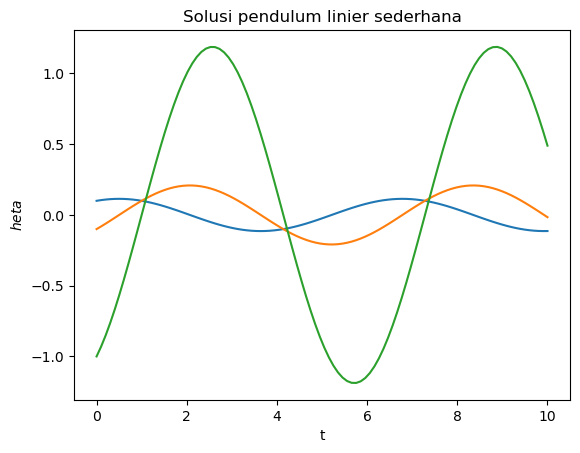

In [11]:
# Solusi pendulum linier sederhana
def linear_pendulum(t, alpha=0.01, beta=0.01, T=1.0):
    C_1 = alpha
    C_2 = (beta - alpha * numpy.cos(T)) / numpy.sin(T)
    return C_1 * numpy.cos(t) + C_2 * numpy.sin(t)


alpha = [0.1, -0.1, -1.0]
beta = [0.1, 0.1, 0.0]
T = [1.0, 1.0, 1.0]
t = numpy.linspace(0, 10.0, 100)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
for i in range(len(alpha)):
    axes.plot(t, linear_pendulum(t, alpha[i], beta[i], T[i]))
axes.set_title("Solusi pendulum linier sederhana")
axes.set_xlabel("t")
axes.set_ylabel("$\theta$")

plt.show()

Namun bagaimana kita menangani masalah yang sepenuhnya non-linier? Pertama, mari kita diskretisasi menggunakan pendekatan kita hingga saat ini dengan aproksimasi beda hingga turunan kedua terpusat orde kedua untuk menemukan
$$
\frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0.
$$

Pendekatan yang paling umum untuk menyelesaikan BVP non-linear seperti ini (dan banyak PDE non-linear lainnya) adalah dengan menggunakan metode Newton. Ingat bahwa jika kita memiliki fungsi non-linear $G(\theta)$ dan kita ingin menemukan $\theta$ sedemikian sehingga
$$
G(\theta) = 0
$$
kita dapat memperluas $G(\theta)$ dalam deret Taylor untuk menemukan
$$
G(\theta^{[k+1]}) = G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]}) + \mathcal{O}((\theta^{[k+1]} - \theta^{[k]})^2)
$$

Jika kita menginginkan $G(\theta^{[k+1]}) = 0$, kita dapat menetapkannya dalam ekspresi di atas (ini juga dikenal sebagai iterasi titik tetap) dan dengan menghilangkan suku-suku orde tinggi, kita dapat menyelesaikan untuk $\theta^{[k+1]}$ untuk menemukan
$$\begin{aligned}
0 &= G(\theta^{[k]}) + G'(\theta^{[k]}) (\theta^{[k+1]} - \theta^{[k]} )\\
G'(\theta^{[k]}) \theta^{[k+1]} &= G'(\theta^{[k]}) \theta^{[k]} - G(\theta^{[k]})
\end{aligned}$$

Pada titik ini kita perlu berhati-hati, jika kita memiliki sistem persamaan, kita tidak bisa begitu saja membagi dengan $G'(\theta^{[k]})$ (yang sekarang berupa matriks) untuk menemukan nilai baru kita $\theta^{[k+1]}$. Sebaliknya, kita perlu membalikkan matriks $G'(\theta^{[k]})$. Cara lain untuk menuliskannya adalah sebagai pembaruan nilai $\theta^{[k+1]}$ di mana
$$
\theta^{[k+1]} = \theta^{[k]} + \delta^{[k]}
$$
di mana
$$
J(\theta^{[k]}) \delta^{[k]} = -G(\theta^{[k]}).
$$

Di sini kami memperkenalkan notasi untuk **matriks Jacobian** yang elemen-elemennya adalah:
$$
J_{ij}(\theta) = \frac{\partial}{\partial \theta_j} G_i(\theta).

$$

Jadi bagaimana kita menghitung matriks Jacobian? Karena kita mengetahui sistem persamaan dalam kasus ini, kita dapat menuliskan secara umum entri-entri dari $J$.

$$
\frac{1}{\Delta t^2}(\theta_{i+1} - 2 \theta_i + \theta_{i-1}) + \sin (\theta_i) = 0.
$$

$$
    J_{ij}(\theta) = \left \{ \begin{aligned}
        &\frac{1}{\Delta t^2} & & j = i - 1, j = i + 1 \\
        -&\frac{2}{\Delta t^2} + \cos(\theta_i) & & j = i \\
        &0 & & \text{jika tidak}
    \end{aligned} \right .
$$

Dengan Jacobian yang sudah ada, kita dapat menyelesaikan BVP dengan melakukan iterasi hingga kriteria penghentian tertentu terpenuhi (kita telah mencapai konvergensi yang memuaskan).

### Contoh

Selesaikan masalah pendulum linear dan non-linear dengan $T=2\pi$, $\alpha = \beta = 0.7$.

- Apakah persamaan linear memiliki solusi tunggal?
- Apakah Anda mengharapkan masalah aslinya memiliki solusi tunggal (yaitu, apakah masalah non-linear memiliki solusi tunggal)?

 (1) Step size: 0.2512782262010663
 (2) Step size: 0.0006452832859468563
 (3) Step size: 1.0760234584263571e-08
 (4) Step size: 1.0872594095386544e-14


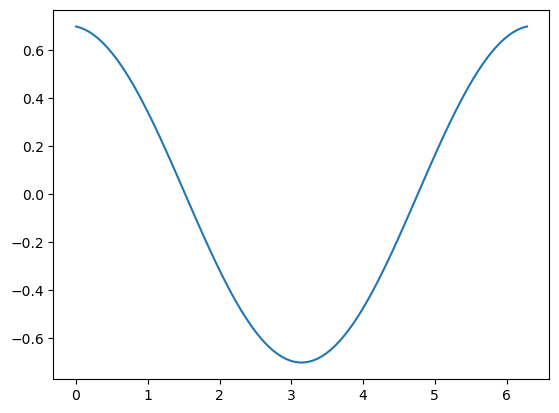

In [17]:
def solve_nonlinear_pendulum(m, alpha, beta, T, max_iterations=100, tolerance=1e-3, verbose=False):
    
    # Diskritisasi
    t_bc = numpy.linspace(0.0, T, m + 2)
    t = t_bc[1:-1]
    delta_t = T / (m + 1)
    diagonal = numpy.ones(t.shape)
    G = numpy.empty(t_bc.shape)
    
    # Tebakan awal
    theta = 0.7 * numpy.cos(t_bc)
    theta[0] = alpha
    theta[-1] = beta
    
    # Loop iterasi utama
    success = False
    for num_step in range(1, max_iterations):
        
        # Membangun matriks Jacobian
        J = numpy.diag(diagonal * -2.0 / delta_t**2 + numpy.cos(theta[1:-1]), 0)
        J += numpy.diag(diagonal[:-1] / delta_t**2, -1)
        J += numpy.diag(diagonal[:-1] / delta_t**2, 1)
        
        # Buat vektor G
        G = (theta[:-2] - 2.0 * theta[1:-1] + theta[2:]) / delta_t**2 + numpy.sin(theta[1:-1])
        
        # Jaga BCs
        G[0] = (alpha - 2.0 * theta[1] + theta[2]) / delta_t**2 + numpy.sin(theta[1])
        G[-1] = (theta[-3] - 2.0 * theta[-2] + beta) / delta_t**2 + numpy.sin(theta[-2])
        
        # Penyelesaian
        delta = numpy.linalg.solve(J, -G)
        theta[1:-1] += delta
        
        if verbose:
            print(" (%s) Step size: %s" % (num_step, numpy.linalg.norm(delta)))
        
        if numpy.linalg.norm(delta) < tolerance:
            success = True
            break
            
    if not success:
        print(numpy.linalg.norm(delta))
        raise ValueError("Reached maximum allowed steps before convergence criteria met.")
    
    return t_bc, theta

t, theta = solve_nonlinear_pendulum(100, 0.7, 0.7, 2.0 * numpy.pi, tolerance=1e-9, verbose=True)
plt.plot(t, theta)
plt.show()

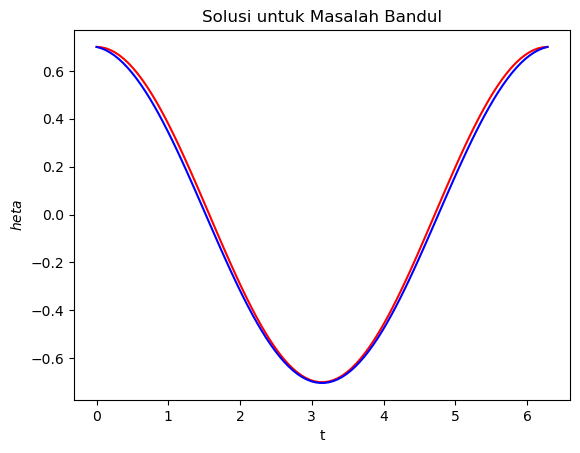

In [19]:
# Masalah Linier
alpha = 0.7
beta = 0.7
T = 2.0 * numpy.pi
t = numpy.linspace(0, T, 100)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, linear_pendulum(t, alpha, beta, T), 'r-', label="Linear")

# Masalah non-linier
t, theta = solve_nonlinear_pendulum(100, alpha, beta, T)
axes.plot(t, theta, 'b-', label="Non-Linear")

axes.set_title("Solusi untuk Masalah Bandul")
axes.set_xlabel("t")
axes.set_ylabel("$\theta$")

plt.show()

### Akurasi

Perhatikan bahwa ada dua gagasan konvergensi yang berbeda yang terjadi pada penyelesai non-linier kita di atas, satu adalah konvergensi aproksimasi beda hingga yang dikendalikan oleh $\Delta x$ dan konvergensi iterasi Newton. Kita mengharapkan keduanya berorde kedua (metode Newton konvergen secara kuadratik di bawah asumsi yang sesuai). Namun, bagaimana kedua metode ini bergabung untuk memengaruhi kesalahan global?

Pertama-tama, mari kita hitung LTE.
$$\begin{aligned}
    \tau_{i} &= \frac{1}{\Delta t^2} (\theta(t_{i+1}) - 2 \theta(t_i) + \theta(t_{i-1})) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta(t_i) + \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 + \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 - 2 \theta(t_i) \right .\\
    &\quad \quad \quad \left . + \theta(t_i) - \theta'(t_i) \Delta t + \frac{1}{2} \theta''(t_i) \Delta t^2 - \frac{1}{6} \theta'''(t_i) \Delta t^3 + \frac{1}{24} \theta^{(4)}(t_i) \Delta t^4 + \mathcal{O}(\Delta t^5) \right) + \sin \theta(t_i) \\
    &= \frac{1}{\Delta t^2} \left (\theta''(t_i) \Delta t^2 + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^4 \mathcal{O}(\Delta t^6) \right) + \sin \theta(t_i) \\
    &= \theta''(t_i)  + \sin \theta(t_i) + \frac{1}{12} \theta^{(4)}(t_i) \Delta t^2 + \mathcal{O}(\Delta t^4).
\end{aligned}$$

Untuk metode Newton, kita dapat mempertimbangkan perbedaan antara mengambil langkah dengan solusi sebenarnya dari BVP $\hat{\theta}$ dibandingkan dengan solusi perkiraan $\theta$. Kita dapat merumuskan LTE analog di mana
$$
G(\Theta) = 0 \quad G(\hat{\Theta}) = \tau.
$$

Melanjutkan diskusi kita sebelumnya, kita dapat menggunakan kedua ekspresi ini untuk menemukan:
$$
G(\Theta) - G(\hat{\Theta}) = -\tau
$$
dan dari sini kita ingin menurunkan ekspresi kesalahan global $E = \Theta - \hat{\Theta}$.

Karena $G(\theta)$ bukan linear, kita akan menulis ekspresi di atas sebagai deret Taylor untuk menemukan
$$
G(\Theta) = G(\hat{\Theta}) + J(\hat{\Theta}) E + \mathcal{O}(||E||^2).

$$

Dengan menggunakan ekspresi ini, kita temukan:
$$
J(\hat{\Theta}) E = -\tau + \mathcal{O}(||E||^2).

$$ Dengan mengabaikan suku-suku orde tinggi, kita memiliki ekspresi linear untuk $E$ yang dapat kita selesaikan.

Hal ini memotivasi definisi stabilitas lain yang melibatkan Jacobian dari $G$. Metode perbedaan nonlinier $G(\Theta) = 0$ adalah *stabil* dalam norma tertentu $||\cdot||$ jika matriks $(J_{\Delta t})^{-1}$ dibatasi secara seragam dalam norma saat $\Delta t \rightarrow 0$. Dengan kata lain, $\exists C$ dan $\Delta t^0$ sedemikian sehingga:

$$
||(J_{\Delta t})^{-1}|| \leq C \quad \forall \Delta t < \Delta t^0.
$$

Dengan asumsi stabilitas dan konsistensi ini ($||\tau|| \rightarrow 0$ saat $\Delta t \rightarrow 0$), maka metode ini konvergen ketika
$$
||E_{\Delta t}|| \rightarrow 0 \quad \text{saat} \quad \Delta t \rightarrow 0.
$$

Perhatikan bahwa kita masih belum dijamin bahwa metode Newton akan konvergen, misalnya dari tebakan awal yang buruk, meskipun kita telah menunjukkan konvergensi. Dapat dibuktikan bahwa metode Newton akan konvergen dari tebakan awal yang cukup baik. Perlu juga dicatat bahwa meskipun metode Newton mungkin memiliki kesalahan yang dibulatkan, hal itu tidak berarti bahwa kesalahan tersebut akan mengikuti pembulatan tersebut.